# Notebook for calculating APWP from the paleopole compilation with a conventional running mean method

In [23]:
import ast 
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

import pandas as pd
from pmagpy import ipmag, pmag
%matplotlib inline
%config InlineBackend.figure_formats = 'retina'

## Import study-level data

In [24]:
Keweenawan_track_study_data = pd.read_csv('../data/pmag_compiled/Keweenawan_pole_means.csv')
Keweenawan_track_study_data['color'] = Keweenawan_track_study_data['color'].apply(lambda x: ast.literal_eval(x))
Keweenawan_track_study_data

,PoleName,SLat,SLon,PLat,PLon,A95,K,N,PolarityZone,PmagRef,AgeNominal,AgeLower,AgeUpper,AgeInfo,AgeRef,Gaussian_2sigma,GaussianOrUniform,Q,color
0,Siemens Creek Volcanics,46.50,269.80,45.8,214.0,9.2,28.3,10,Alona Bay reversed-polarity zone,"Palmer and Halls, 1986",1108.00,1105.000,1110.000,Older than the $^{\mathrm{207}}$Pb/$^{\mathrm{...,"Davis and Green, 1997",NaN,uniform,6,"(0.281446, 0.08432, 0.407414, 1.0)"
1,Osler reverse (lower),48.80,272.34,40.9,218.6,4.8,31.5,30,Alona Bay reversed-polarity zone,"Swanson-Hysell et al., 2014b",1108.00,1105.150,1110.000,Older than 1105.15 $\pm$ 0.33 Ma Osler reverse...,"Davis and Sutcliffe, 1985; this study",NaN,uniform,7,"(0.281446, 0.08432, 0.407414, 1.0)"
2,Osler reverse (upper),48.59,271.81,42.3,203.4,3.7,24.4,64,Alona Bay reversed-polarity zone,"Halls, 1974; Swanson-Hysell et al., 2014b; Swa...",1105.15,1104.820,1105.480,$^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date of...,"Swanson-Hysell et al., 2019",0.33,gaussian,7,"(0.276194, 0.190074, 0.493001, 1.0)"
3,Osler normal,48.64,271.91,32.0,171.9,9.7,90.9,4,Portage Lake normal-polarity zone,"Halls, 1974; Swanson-Hysell et al., 2019",1095.00,1080.000,1100.000,"Poorly known, significantly younger than the c...","Swanson-Hysell et al., 2019",NaN,uniform,7,"(0.153364, 0.497, 0.557724, 1.0)"
4,Mamainse lower reversed 1,47.10,275.29,49.5,227.0,5.3,31.7,24,Alona Bay reversed-polarity zone,"Swanson-Hysell et al., 2014a",1109.00,1106.000,1112.000,Likely older than ca. 1105 Ma given distinct h...,"Swanson-Hysell et al., 2019",NaN,uniform,7,"(0.276022, 0.044167, 0.370164, 1.0)"
5,Mamainse lower reversed 2,47.09,275.27,37.5,205.2,4.5,78.6,14,Alona Bay reversed-polarity zone,"Swanson-Hysell, 2014a",1105.00,1100.400,1109.000,Older than $^{\mathrm{206}}$Pb/$^{\mathrm{238}...,"Swanson-Hysell, 2014a",NaN,uniform,7,"(0.275191, 0.194905, 0.496005, 1.0)"
6,Mamainse lower normal and upper reversed,47.07,275.26,36.1,189.7,4.9,37.3,24,Flour Bay normal and reversed polarity zones,"Swanson-Hysell, 2014a",1100.36,1100.100,1100.610,Age constrained by $^{\mathrm{206}}$Pb/$^{\mat...,"Swanson-Hysell, 2014a",0.25,gaussian,7,"(0.21813, 0.347432, 0.550038, 1.0)"
7,Mamainse upper normal,47.06,275.25,31.2,183.2,2.5,94.4,34,Portage Lake normal-polarity zone,"Swanson-Hysell, 2014a",1094.00,1090.000,1100.000,Likely ca. 1094 Ma based on similar pole posit...,"Swanson-Hysell et al., 2019",NaN,uniform,7,"(0.141935, 0.526453, 0.555991, 1.0)"
8,Grand Portage Basalts,47.93,270.28,46.0,201.7,6.8,38.4,13,Alona Bay reversed-polarity zone,"Books, 1968; Tauxe and Kodama, 2009",1106.00,1105.280,1108.000,"Close to, but slightly older than, $^{\mathrm{...","Swanson-Hysell et al., 2019",NaN,uniform,5,"(0.280868, 0.160771, 0.472899, 1.0)"
9,North Shore Volcanic Group (upper SW sequence),47.20,268.50,36.7,179.3,2.1,55.0,87,Portage Lake normal-polarity zone,"Tauxe and Kodama, 2009; Swanson-Hysell et al.,...",1096.18,1093.940,1096.750,$^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date on...,"Swanson-Hysell et al., 2019",1.12,gaussian,6,"(0.165117, 0.467423, 0.558141, 1.0)"


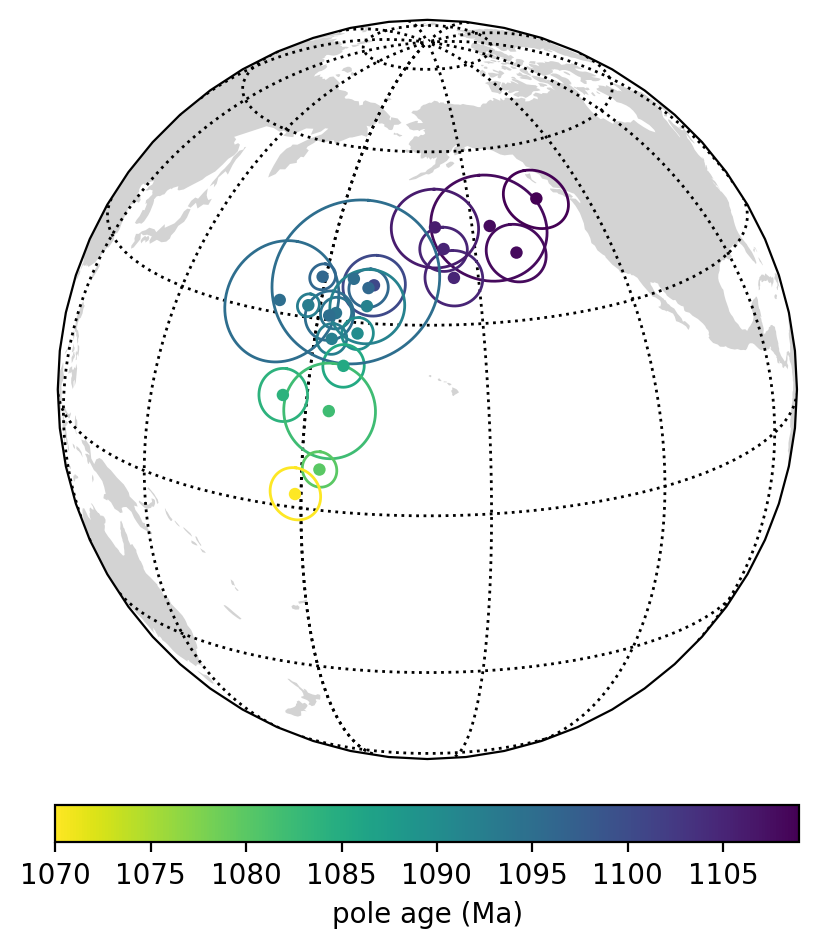

In [25]:
ax = ipmag.make_orthographic_map(200, 20, figsize=(6,6), land_color='lightgrey', ocean_color=None, land_edge_color=None)
ipmag.plot_poles_colorbar(ax, Keweenawan_track_study_data['PLon'], Keweenawan_track_study_data['PLat'], 
                              Keweenawan_track_study_data['A95'], colorvalues=Keweenawan_track_study_data['AgeNominal'], colormap='viridis_r',
                              vmin=Keweenawan_track_study_data['AgeNominal'].min(), vmax=Keweenawan_track_study_data['AgeNominal'].max(), filled_pole=0, fill_alpha=0.5, edgecolor='none')

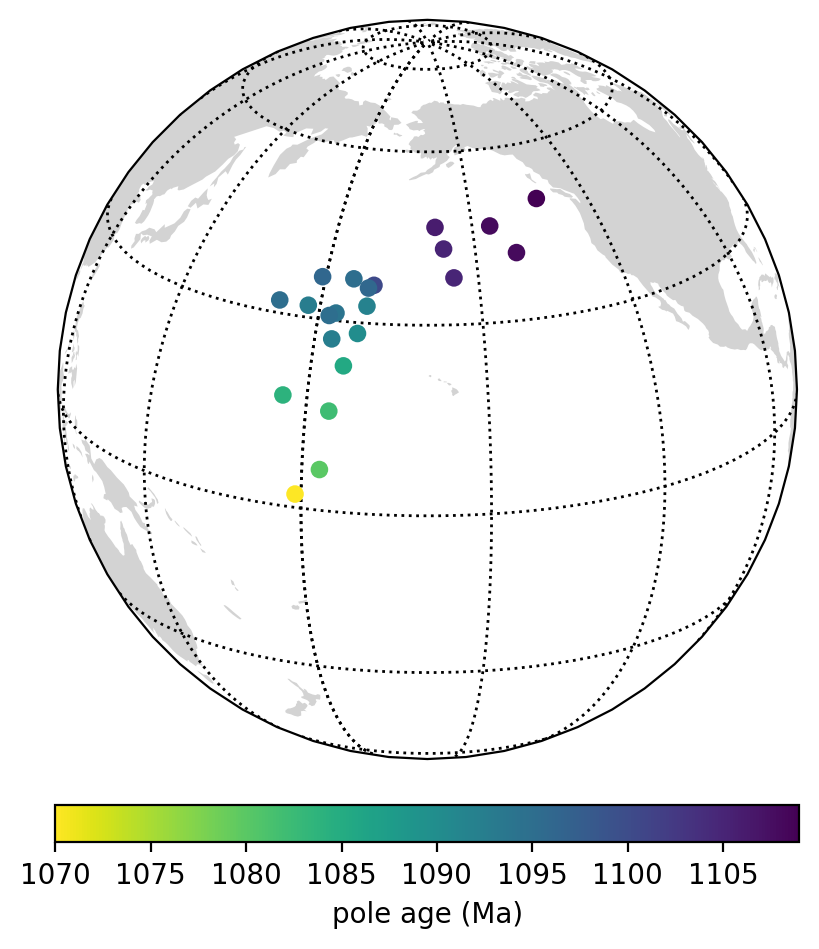

In [26]:
ax = ipmag.make_orthographic_map(200, 20, figsize=(6,6), land_color='lightgrey', ocean_color=None, land_edge_color=None)
ipmag.plot_poles_colorbar(ax, Keweenawan_track_study_data['PLon'], Keweenawan_track_study_data['PLat'], 
                              np.zeros(Keweenawan_track_study_data.shape[0]), colorvalues=Keweenawan_track_study_data['AgeNominal'], colormap='viridis_r',
                              vmin=Keweenawan_track_study_data['AgeNominal'].min(), vmax=Keweenawan_track_study_data['AgeNominal'].max(), edgecolor='none', markersize=40)

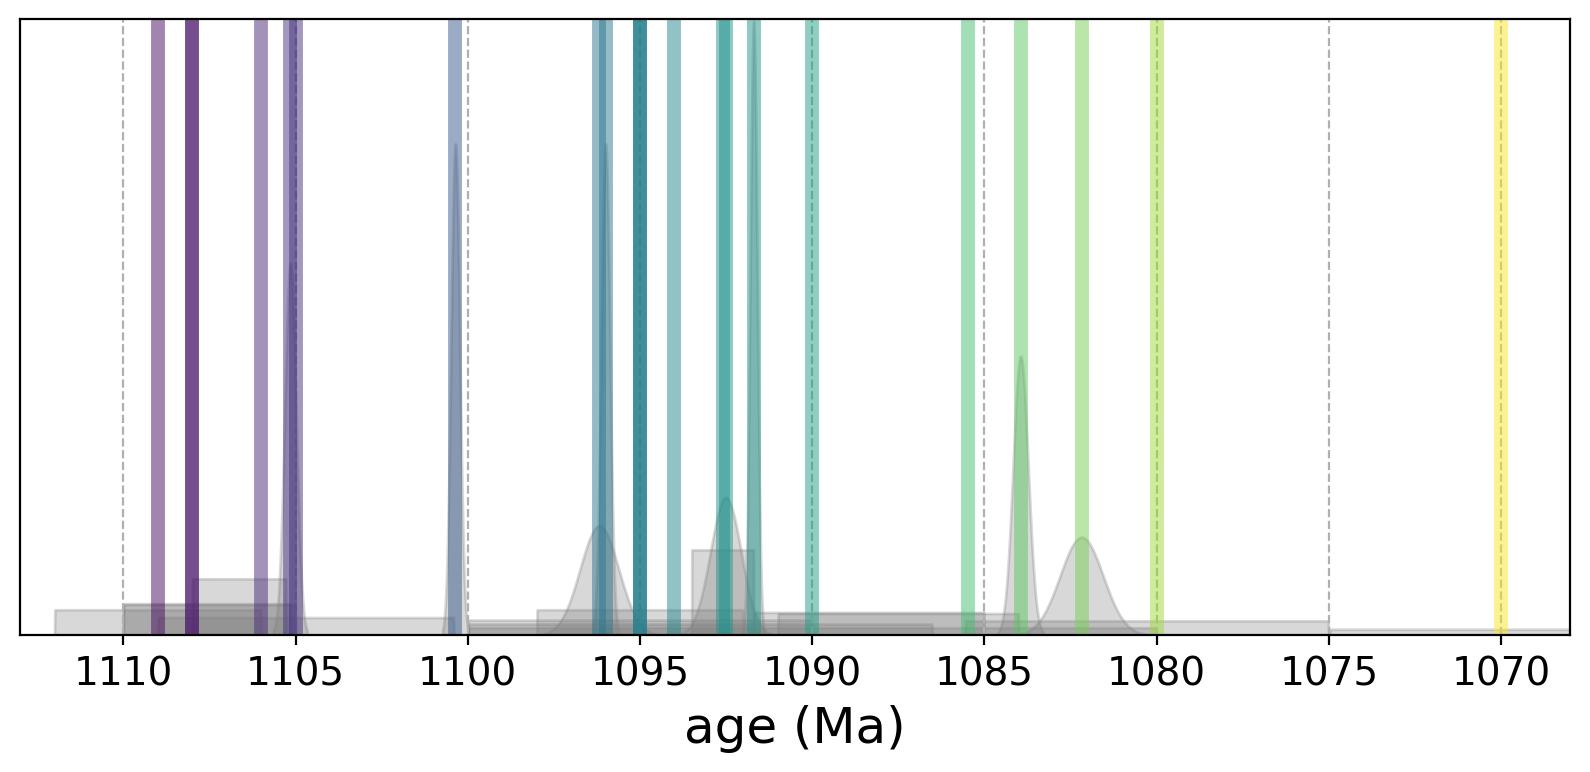

In [27]:
plt.figure(figsize = (10, 4))
for i in range(Keweenawan_track_study_data.shape[0]):
    plt.axvline(Keweenawan_track_study_data['AgeNominal'][i], color = Keweenawan_track_study_data['color'][i], lw=5, alpha=0.5)
    max_y = 0
    if Keweenawan_track_study_data['GaussianOrUniform'][i] == 'uniform':
        x = np.linspace(Keweenawan_track_study_data['AgeLower'][i], Keweenawan_track_study_data['AgeUpper'][i], 500)
        y = np.zeros(500)
        y[(x< Keweenawan_track_study_data['AgeUpper'][i]) & (x>Keweenawan_track_study_data['AgeLower'][i])] = 1.0/(Keweenawan_track_study_data['AgeUpper'][i]-Keweenawan_track_study_data['AgeLower'][i])
        if max_y < max(y):
            max_y = max(y)

    else: 
        mu = Keweenawan_track_study_data['AgeNominal'][i]
        sigma = Keweenawan_track_study_data['Gaussian_2sigma'][i]/2

        x = np.linspace(mu-3*sigma,mu+3*sigma, 1000)
        y = st.norm.pdf(x, mu, sigma)
        if max_y < max(y):
            max_y = max(y)
    # plt.plot(x, y, color = pole_means['color'][i], lw=0.5, alpha=0.5)
    plt.fill_between(x, y, color = 'grey', alpha = 0.3)
plt.grid(1, ls='--')
plt.xlim(1068, 1113)
plt.ylim(0, 4)

plt.xlabel('age (Ma)', fontsize=18)
# plt.ylabel('Prior\nprobability', fontsize=14)
# plt.yticks([0, 1, 2, 3, 4], fontsize=14)
plt.yticks([])
plt.xticks(fontsize=14)
plt.gca().invert_xaxis()
# plt.savefig('../figure/Keweenawan_running_mean_age_distribution.pdf', bbox_inches='tight')
plt.show()


## Running mean APWP

One of the most commonly used method of synthesizing APWP is to do a running mean calculation with a user-defined window size over study-level paleomagnetic poles. This approach has the simplicity of calculating parametric Fisher means of study-level poles. However it has many disadvantages. It does not propagate uncertainties of site-level data into running mean poles. It has the assumption that the running mean study-level poles are Fisher distributed. It takes mean of study-level poles which could bias the mean poles into regions of high study-level pole density. It did not take into account ages and age uncertainties of study-level poles. 

We will show the running mean Keweenawan Track here as was done in Swanson-Hysell et al., 2019.

In [28]:
def running_mean_APWP(data,window_length,spacing,max_age,min_age, central_longitude=200, central_latitude=20, pole_alpha=0.8, colorbar=True, figsize=(5,5)):
    '''
    function for calculating running mean poles at the formation level 

    Parameters
    ----------
    data : DataFrame
        paleomagnetic pole mean DataFrame
    window_length : int
        length of the running mean window in Ma
    spacing : int
        spacing of the running mean poles in Ma
    max_age : int
        maximum age of the running mean poles in Ma
    min_age : int
        minimum age of the running mean poles in Ma
    '''
    mean_pole_ages = np.arange(min_age,max_age+spacing,spacing)
    running_means = pd.DataFrame(columns=['age','N','A95','PLon','PLat'])
    for age in mean_pole_ages:
        window_min = age - (window_length/2)
        window_max = age + (window_length/2)
        poles = data.loc[(data['AgeNominal'] >= window_min) & (data['AgeNominal'] <= window_max)]
        mean = ipmag.fisher_mean(dec=poles['PLon'].tolist(),inc=poles['PLat'].tolist())
        # print(mean)
        running_means.loc[age] = [age, mean['n'], mean['alpha95'], mean['dec'], mean['inc']]
        
    m = ipmag.make_orthographic_map(central_longitude=central_longitude,central_latitude=central_latitude,
                                     land_color='lightgrey',land_edge_color=None, figsize=figsize)
    ipmag.plot_vgp(m, data['PLon'], data['PLat'], color='black', label='underlying pole means', edge=None, alpha=0.5)

    ipmag.plot_poles_colorbar(m, running_means['PLon'].tolist(), 
                              running_means['PLat'].tolist(), 
                              running_means['A95'].tolist(), 
                              colorvalues=running_means['age'].tolist(), 
                              colormap='viridis_r',
                              vmin=min_age, vmax=max_age, 
                              filled_pole=0, alpha=pole_alpha, 
                              fill_alpha=pole_alpha, edgecolor='none', colorbar=colorbar, lw=2)
    return running_means, m

### running mean with 20 Myr window size and 10 Myr spacing between 1110 and 1070 Ma

(         age     N        A95        PLon       PLat
 1070  1070.0   2.0  12.830128  180.944234   4.402539
 1080  1080.0   6.0   8.871167  182.376986  15.641052
 1090  1090.0  14.0   4.857146  182.559293  27.700307
 1100  1100.0  17.0   6.070520  192.167063  37.433497
 1110  1110.0   7.0   7.655953  207.947114  43.150002,
 <GeoAxes: >)

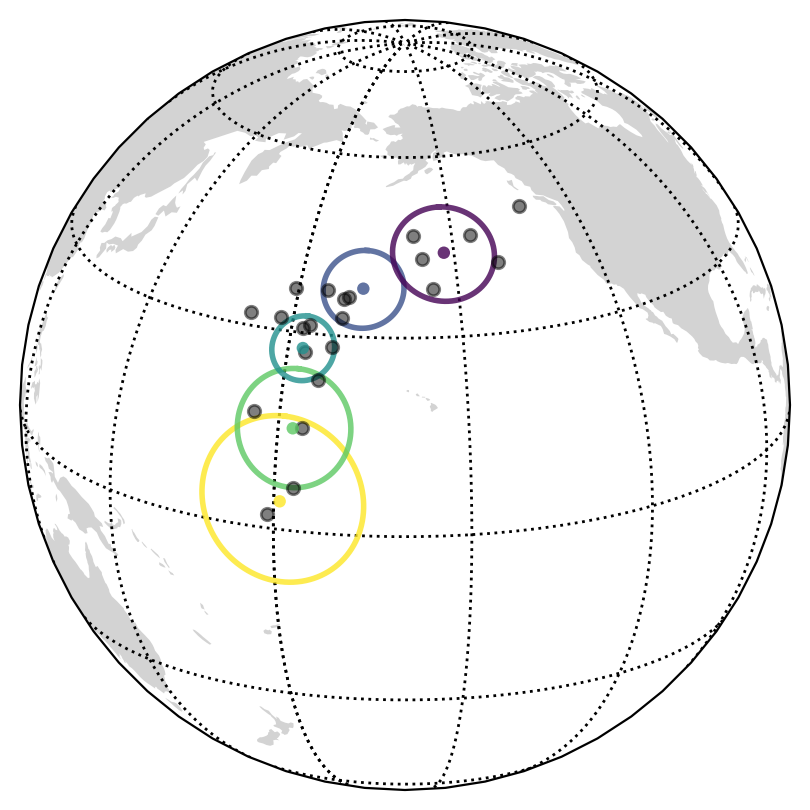

In [29]:
RM_20_10_1110_1070 = running_mean_APWP(Keweenawan_track_study_data,20,10,1110,1070, pole_alpha=0.8, colorbar=False)
# plt.savefig('../figure/Keweenawan_running_mean_poles_20_10.pdf', bbox_inches='tight')
RM_20_10_1110_1070

### running mean with 20 Myr window size and 1 Myr spacing between 1115 and 1070 Ma

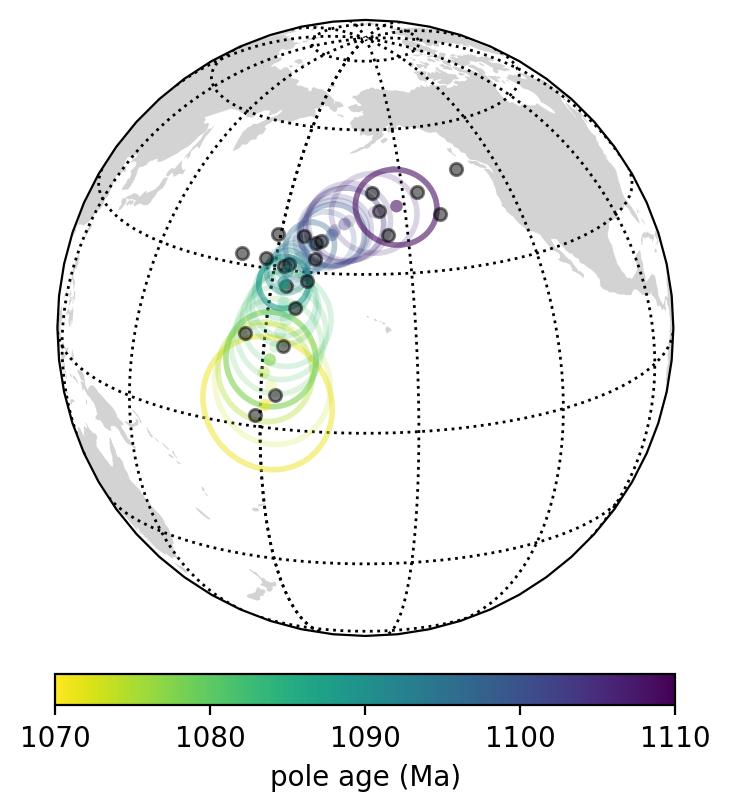

In [30]:
#RM_20_10_1115_1075 = running_mean_APWP(pole_means,20,10,1115,1075,fig_name='running_mean')
RM_20_1_1115_1070_df, RM_20_1_1115_1070_m = running_mean_APWP(Keweenawan_track_study_data,20,1,1110,1070, pole_alpha=0.2)

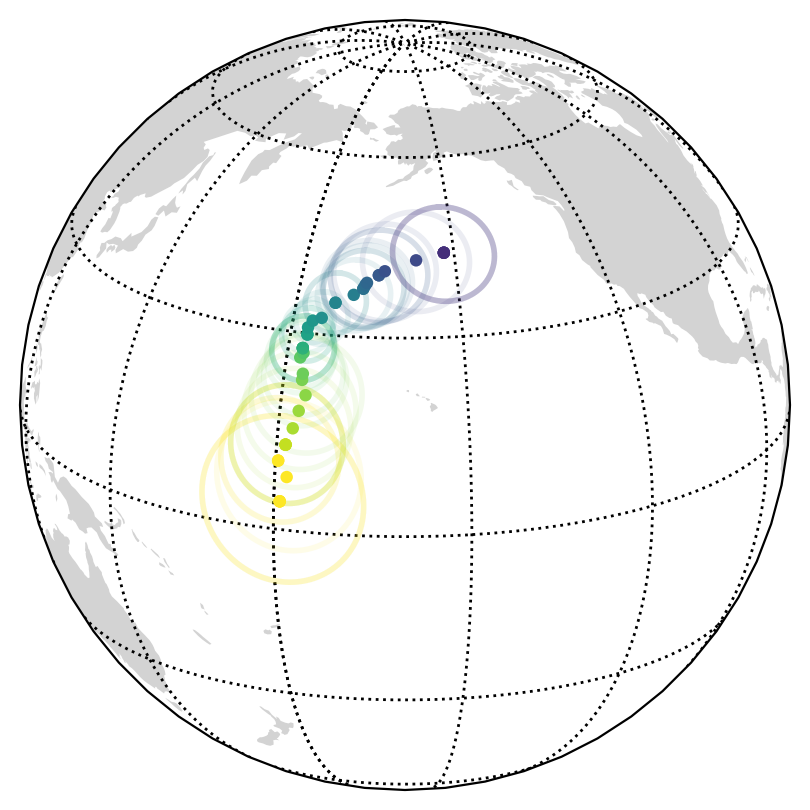

In [31]:
ax = ipmag.make_orthographic_map(200, 20, ocean_color=None, land_edge_color=None, land_color='lightgrey', figsize=(5,5))
ipmag.plot_poles_colorbar(ax, RM_20_1_1115_1070_df['PLon'].tolist(), RM_20_1_1115_1070_df['PLat'].tolist(), 
                              np.zeros(RM_20_1_1115_1070_df.shape[0]), colorvalues=RM_20_1_1115_1070_df['age'].tolist(), colormap='viridis_r',
                              vmin=1075, vmax=1115, filled_pole=0, fill_alpha=0.6, edgecolor='none', colorbar=0)
ipmag.plot_poles_colorbar(ax, RM_20_1_1115_1070_df['PLon'].tolist(), RM_20_1_1115_1070_df['PLat'].tolist(), 
                        RM_20_1_1115_1070_df['A95'].tolist(), colorvalues=RM_20_1_1115_1070_df['age'].tolist(), colormap='viridis_r',
                        vmin=1075, vmax=1115, filled_pole=False, alpha=0.1, edgecolor='none', colorbar=0, lw=2)
# plt.savefig('../figure/Keweenawan_running_mean_poles_20_1.pdf', bbox_inches='tight')                         
# RM_20_1_1115_1070_df